# 3 — Imputation and forecasting, without retraining

The model from notebook 1 was trained unconditionally. The linear interpolation
it was trained on gives a direct way to enforce observations at sampling time,
so the same checkpoint does imputation and forecasting with no retraining, no
auxiliary network and **no additional function evaluations**.

Let $\mathbf{y}$ be a target sequence and $m$ mark its observed entries. Given
the velocity $\mathbf{v}$ at $(\mathbf{x}_t, t)$, the division-free clean
estimate and the noise it implies are

$$\hat{\mathbf{x}}_0 = \mathbf{x}_t - t\mathbf{v}, \qquad
  \hat{\varepsilon} = \hat{\mathbf{x}}_0 + \mathbf{v},$$

and together they reproduce the state exactly. Writing the observation into
$\hat{\mathbf{x}}_0$ and re-forming the state at the next time $t'$ gives the
update used here:

$$\mathbf{x}_{t'} \leftarrow
  m \odot \big[(1-t')\mathbf{y} + t'\hat{\varepsilon}\big] +
  (1-m) \odot \big[\mathbf{x}_t + (t'-t)\mathbf{v}\big].$$

Wherever $m=0$ this is the plain Euler step, so conditioning changes the update
rule only at the observed entries — where it holds the observation carried to
$t'$ along the training interpolation, noised by the realisation the model
itself implies.

The textbook form instead overwrites the state with the observation re-noised by
an independently drawn $\varepsilon$. That splices a model-independent
trajectory into the state the next evaluation reads, and the hidden region has
no way to reconcile with a trajectory it did not produce.

In [1]:
import os
# torch and scikit-learn each bring their own OpenMP runtime; inside a Jupyter
# kernel the two can collide and take the kernel down when t-SNE runs after a
# torch import. Capping the thread pools before either is imported avoids it.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import sys, json
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("scripts"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from conditional import (load_run, impute_mask, forecast_mask, complete_k,
                         scores, linear_fill, last_value_fill)

plt.rcParams.update({"figure.dpi": 120, "font.size": 8,
                     "axes.spines.top": False, "axes.spines.right": False})
REAL_C, GEN_C, OBS_C = "#A82424", "#17548C", "#EDEDED"

In [2]:
DATASET = "sines"      # must match notebook 1
N_SEQ   = 250          # held-out sequences per configuration
K_DRAWS = 10           # completions drawn per masked input
STEPS   = 20           # Euler steps per segment; 4 x 20 = the NFE 80 budget

model, flow, cfg, dev, real_all = load_run(DATASET, os.path.join("results", "run"))
real = real_all[:N_SEQ]
T = real.shape[1]
print(f"{DATASET}: {real.shape} held-out sequences on {dev}")
print(f"segments {cfg.flow.segments} x {STEPS} Euler steps = NFE {cfg.flow.segments * STEPS}")

sines: (250, 64, 4) held-out sequences on mps
segments 4 x 20 Euler steps = NFE 80


## Imputation

Entries are hidden in contiguous streaks whose lengths are geometric with mean
three. Contiguous streaks matter: isolated missing values are often recoverable
by interpolation alone and make a much less demanding test.

Under *separate* masking the streaks are drawn independently per channel; under
*concurrent* masking the same timesteps are hidden in every channel, which is
harder because it removes the option of inferring a missing channel from the
observed ones at that step.

In [3]:
RATIO, STYLE = 0.5, "separate"

rng = np.random.default_rng(0)
keep = impute_mask(real.shape, RATIO, STYLE, 3, rng)
preds, nfe = complete_k(model, flow, cfg, dev, real * keep, keep, STEPS, K_DRAWS, seed=0)
s = scores(preds, real, keep)

ref = float((((linear_fill(real * keep, keep) - real)[~keep]) ** 2).mean())
print(f"hidden fraction          {float((~keep).mean()):.2f}")
print(f"MSE of {K_DRAWS}-sample mean   {s['mse_mean']:.5f}")
print(f"linear interpolation     {ref:.5f}   ({ref / s['mse_mean']:.1f}x)")
print(f"CRPS                     {s['crps']:.5f}")
print(f"max error at observed    {s['obs_max_abs']:.1e}")
print(f"function evaluations     {nfe}  (the unconditional budget)")

hidden fraction          0.50
MSE of 10-sample mean   0.00016
linear interpolation     0.02475   (151.9x)
CRPS                     0.00386
max error at observed    0.0e+00
function evaluations     80  (the unconditional budget)


Two things to read off that. The error at observed entries is exactly zero —
at $t=0$ the carried target is $\mathbf{y}$ itself, so every observation is
reproduced. And the evaluation count is the unconditional one: the update is
elementwise arithmetic and adds no network evaluations.

The comparison is against linear interpolation rather than another generator.
That is a scale, not a competitor: under a random walk it is the Brownian-bridge
conditional mean of a missing interior value, so on series with random-walk-like
increments it is close to optimal rather than weak.

### Why the $K$-sample mean

A conditional generator produces several plausible completions, whereas squared
error is minimised by a single value — the conditional mean. Scoring one random
draw would penalise exactly the predictive variation a calibrated model should
have. So the $K$ completions are averaged and that mean is scored, which is also
what the deterministic reference already computes.

In [4]:
print(f"single draw   {s['mse']:.5f}")
print(f"{K_DRAWS}-sample mean {s['mse_mean']:.5f}   "
      f"({s['mse'] / s['mse_mean']:.1f}x lower)")

single draw   0.00050
10-sample mean 0.00016   (3.1x lower)


## Forecasting

The final $h$ steps of every channel are hidden. The reference repeats the last
observed value, which is the optimal forecast under a random walk.

In [5]:
rows = []
for frac in (0.125, 0.25, 0.5):
    h = max(1, int(round(frac * T)))
    km = forecast_mask(real.shape, h)
    pf, _ = complete_k(model, flow, cfg, dev, real * km, km, STEPS, K_DRAWS, seed=0)
    sf = scores(pf, real, km)
    rf = float((((last_value_fill(real, h) - real)[~km]) ** 2).mean())
    rows.append((frac, h, sf["mse_mean"], rf, sf["crps"]))
    print(f"h = T/{round(1/frac):<2d} ({h:3d} steps)   MSE {sf['mse_mean']:.5f}   "
          f"last-value {rf:.5f}   ({rf / sf['mse_mean']:.1f}x)   CRPS {sf['crps']:.5f}")

h = T/8  (  8 steps)   MSE 0.00157   last-value 0.24027   (152.8x)   CRPS 0.01905
h = T/4  ( 16 steps)   MSE 0.00517   last-value 0.85489   (165.5x)   CRPS 0.03229
h = T/2  ( 32 steps)   MSE 0.04684   last-value 1.08125   (23.1x)   CRPS 0.08711


## What a completion looks like

The tinted span is what the model was given; everything on white it had to
invent. The band is the 10th to 90th percentile over the drawn completions and
the solid line their median.

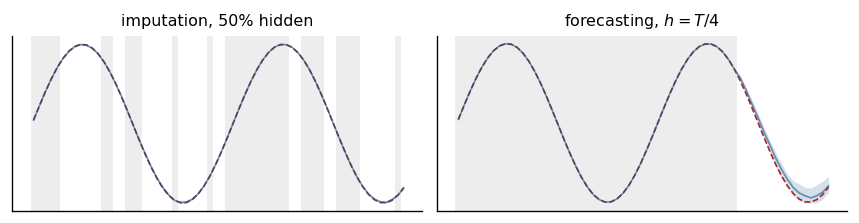

In [6]:
def runs(k, observed):
    out, i, n = [], 0, len(k)
    while i < n:
        if bool(k[i]) == observed:
            j = i
            while j + 1 < n and bool(k[j + 1]) == observed:
                j += 1
            out.append((i, j - i + 1)); i = j + 1
        else:
            i += 1
    return out

def fan(ax, preds, real, keep, idx, f):
    for st, ln in runs(keep[idx, :, f], True):
        ax.axvspan(st - .5, st + ln - .5, facecolor=OBS_C, lw=0, zorder=0)
    P = preds[:, idx, :, f]
    t = np.arange(real.shape[1])
    ax.fill_between(t, np.percentile(P, 10, 0), np.percentile(P, 90, 0),
                    color=GEN_C, alpha=.18, lw=0, zorder=2)
    ax.plot(real[idx, :, f], color=REAL_C, lw=1.0, ls=(0, (3.5, 1.6)), zorder=4)
    ax.plot(np.median(P, 0), color=GEN_C, lw=1.0, alpha=.6, zorder=5)
    ax.set_xticks([]); ax.set_yticks([])

# a mid-range example rather than a best case
f = 0
hid = ~keep[:, :, f]
err = (((np.median(preds[:, :, :, f], 0) - real[:, :, f]) ** 2) * hid).sum(1) / np.maximum(hid.sum(1), 1)
order = np.argsort(err)
idx = int(order[len(order) // 3])

h = max(1, int(round(0.25 * T)))
km = forecast_mask(real.shape, h)
pf, _ = complete_k(model, flow, cfg, dev, real * km, km, STEPS, K_DRAWS, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 1.9))
fan(axes[0], preds, real, keep, idx, f); axes[0].set_title(f"imputation, {int(RATIO*100)}% hidden")
fan(axes[1], pf, real, km, idx, f); axes[1].set_title("forecasting, $h=T/4$")
fig.tight_layout(); plt.show()

## The full protocol

`scripts/conditional.py` runs every configuration reported in the paper — five
hidden fractions by two masking styles, three forecast horizons, 250 held-out
sequences with ten completions each:

```bash
python scripts/conditional.py --datasets sines --ratios 0.1,0.3,0.5,0.7,0.9 \
    --styles separate,concurrent --horizons 0.125,0.25,0.5 --n 250 --k 10
```

Conditioning this way enforces the observations exactly, but it is an
approximate conditioning method rather than an exact sampler from the
conditional distribution.